# EDA: Detección de Fraude en Pagos Digitales

# Objetivo: 

## 1. Carga de datos

In [2]:
#Activemos el ambiente  en cmd .venv\Scripts\activate
#Importamos las librerías para usar en el EDA
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
#Cargamos el dataset en csv que se encuentra en la carpeta
df= pd.read_csv('Digital_Payment_Fraud_Detection_Dataset.csv')

print('Archivo Pagos Cargado Exitosamente')

#Previsualizamos la información para ver que columnas tiene y que información puede estar en cada columna
df.head(3)

Archivo Pagos Cargado Exitosamente


,transaction_id,user_id,transaction_amount,transaction_type,payment_mode,device_type,device_location,account_age_days,transaction_hour,previous_failed_attempts,avg_transaction_amount,is_international,ip_risk_score,login_attempts_last_24h,fraud_label
0,T1,U3756,18758.28,Transfer,UPI,Web,Hyderabad,895,14,1,25535.84,0,0.718,4,0
1,T2,U7899,47538.18,Payment,Wallet,iOS,Hyderabad,918,21,0,3955.85,0,0.525,9,0
2,T3,U1765,36613.10,Payment,Card,Android,Chennai,1506,8,4,22727.71,0,0.985,9,0


# 2. Descripción del Dataset

Tenemos 15 columnas, 7500 transacciones de 5106 usuarios. Hay 3 tipos de transacciones, Transferencias, Pagos y Retiros.

In [12]:
df.sample(n=10, random_state=10)

,transaction_id,user_id,transaction_amount,transaction_type,payment_mode,device_type,device_location,account_age_days,transaction_hour,previous_failed_attempts,avg_transaction_amount,is_international,ip_risk_score,login_attempts_last_24h,fraud_label
4984,T4985,U7989,27555.49,Withdrawal,Card,Web,Bangalore,900,22,1,7270.27,0,0.917,1,0
1852,T1853,U8878,43075.43,Payment,UPI,Web,Chennai,515,17,0,15360.09,0,0.995,9,0
66,T67,U9847,7089.17,Transfer,Card,Android,Hyderabad,1800,22,4,24550.03,0,0.585,9,0
216,T217,U6936,16303.71,Withdrawal,Card,Android,Delhi,745,1,4,12963.44,0,0.187,8,0
5911,T5912,U6902,46332.94,Withdrawal,UPI,Web,Bangalore,405,6,0,18304.86,0,0.017,4,0
5526,T5527,U5090,31966.20,Transfer,UPI,iOS,Delhi,875,8,0,6241.30,0,0.798,3,0
191,T192,U6183,44865.93,Transfer,Wallet,Android,Delhi,1038,1,4,4224.42,0,0.556,8,0
5610,T5611,U3713,3894.61,Withdrawal,Wallet,iOS,Mumbai,1816,21,3,14820.23,0,0.238,1,0
7421,T7422,U3944,34519.26,Withdrawal,Card,Android,Chennai,1527,20,3,17741.98,0,0.591,8,1
7155,T7156,U4289,41146.87,Transfer,Wallet,iOS,Hyderabad,1872,7,0,16820.48,0,0.265,5,0


In [4]:
print("\n🔍 Paso 2: Descripción del dataset")
print("-" * 40)
# 1. Número de filas y columnas
filas, columnas = df.shape

# 2. Información de cada columna
df.info()

# 3. Diccionario simple de datos
info_columnas = pd.DataFrame({
    'Tipo de Dato': df.dtypes,
    'Valores Nulos': df.isnull().sum(),
    'Valores Únicos': df.nunique()
})
display(info_columnas)


🔍 Paso 2: Descripción del dataset
----------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   transaction_id            7500 non-null   object 
 1   user_id                   7500 non-null   object 
 2   transaction_amount        7500 non-null   float64
 3   transaction_type          7500 non-null   object 
 4   payment_mode              7500 non-null   object 
 5   device_type               7500 non-null   object 
 6   device_location           7500 non-null   object 
 7   account_age_days          7500 non-null   int64  
 8   transaction_hour          7500 non-null   int64  
 9   previous_failed_attempts  7500 non-null   int64  
 10  avg_transaction_amount    7500 non-null   float64
 11  is_international          7500 non-null   int64  
 12  ip_risk_score             7500 non-null   

,Tipo de Dato,Valores Nulos,Valores Únicos
transaction_id,object,0,7500
user_id,object,0,5106
transaction_amount,float64,0,7499
transaction_type,object,0,3
payment_mode,object,0,4
device_type,object,0,3
device_location,object,0,5
account_age_days,int64,0,1943
transaction_hour,int64,0,24
previous_failed_attempts,int64,0,5


In [ ]:
#Revisemos estadística basica para cada columna
df.describe()

,transaction_amount,account_age_days,transaction_hour,previous_failed_attempts,avg_transaction_amount,is_international,ip_risk_score,login_attempts_last_24h,fraud_label
count,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000
mean,24813.534161,1006.904533,11.435867,2.013600,15129.061027,0.100667,0.505026,4.995067,0.065200
std,14434.742371,575.632925,6.950899,1.421578,8597.760720,0.300907,0.289647,2.593879,0.246895
min,50.580000,10.000000,0.000000,0.000000,102.790000,0.000000,0.000000,1.000000,0.000000
25%,12272.785000,502.750000,5.000000,1.000000,7725.842500,0.000000,0.257000,3.000000,0.000000
50%,24715.550000,1018.000000,11.000000,2.000000,15074.810000,0.000000,0.502000,5.000000,0.000000
75%,37288.375000,1505.000000,18.000000,3.000000,22573.062500,0.000000,0.759000,7.000000,0.000000
max,49985.900000,1999.000000,23.000000,4.000000,29994.290000,1.000000,1.000000,9.000000,1.000000


In [16]:
# Revisemos la estadistica basica sólo para lo que este marcado como fraude
df_fraude = df[df['fraud_label'] == 1]
df_fraude.describe()

,transaction_amount,account_age_days,transaction_hour,previous_failed_attempts,avg_transaction_amount,is_international,ip_risk_score,login_attempts_last_24h,fraud_label
count,489.000000,489.000000,489.000000,489.000000,489.000000,489.000000,489.000000,489.000000,489.0
mean,24256.210879,1071.456033,11.568507,2.096115,15310.463313,0.083845,0.508689,5.155419,1.0
std,14289.574936,566.853237,6.873261,1.418902,8702.706731,0.277438,0.301381,2.557610,0.0
min,245.720000,10.000000,0.000000,0.000000,392.350000,0.000000,0.000000,1.000000,1.0
25%,11770.370000,564.000000,6.000000,1.000000,7576.580000,0.000000,0.245000,3.000000,1.0
50%,24260.580000,1108.000000,12.000000,2.000000,15421.840000,0.000000,0.485000,5.000000,1.0
75%,35936.770000,1566.000000,18.000000,3.000000,22738.260000,0.000000,0.790000,7.000000,1.0
max,49985.900000,1996.000000,23.000000,4.000000,29826.310000,1.000000,0.995000,9.000000,1.0


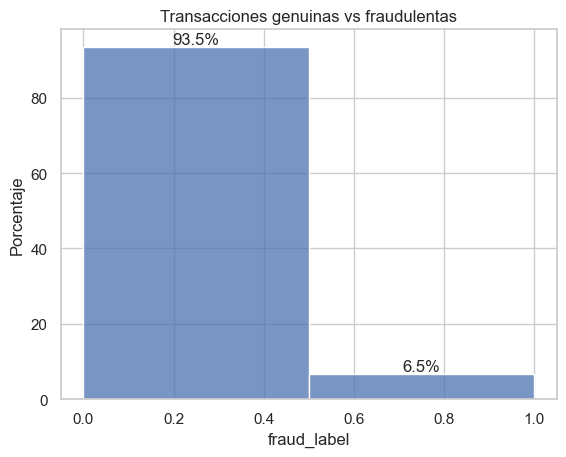

In [18]:
#Veamos que porcentaje de transacciones son reales vs fraudulentas
plt.title('Transacciones genuinas vs fraudulentas')
ax = sns.histplot(df['fraud_label'], bins=2, stat="percent")

# Agregamos el porcentaje a cada barra
for p in ax.patches:
    porcentaje = p.get_height()
    ax.annotate(f'{porcentaje:.1f}%', 
                (p.get_x() + p.get_width() / 2, porcentaje),
                ha='center', va='bottom')

plt.ylabel("Porcentaje")
plt.show()

# Exploramos las variables a detalle


A. ¿La hora del día en la que se hace la transacción, tiene relación con la marcación de fraude?


🔍  Histograma
----------------------------------------
fraud_label
0    0.9348
1    0.0652
Name: proportion, dtype: float64


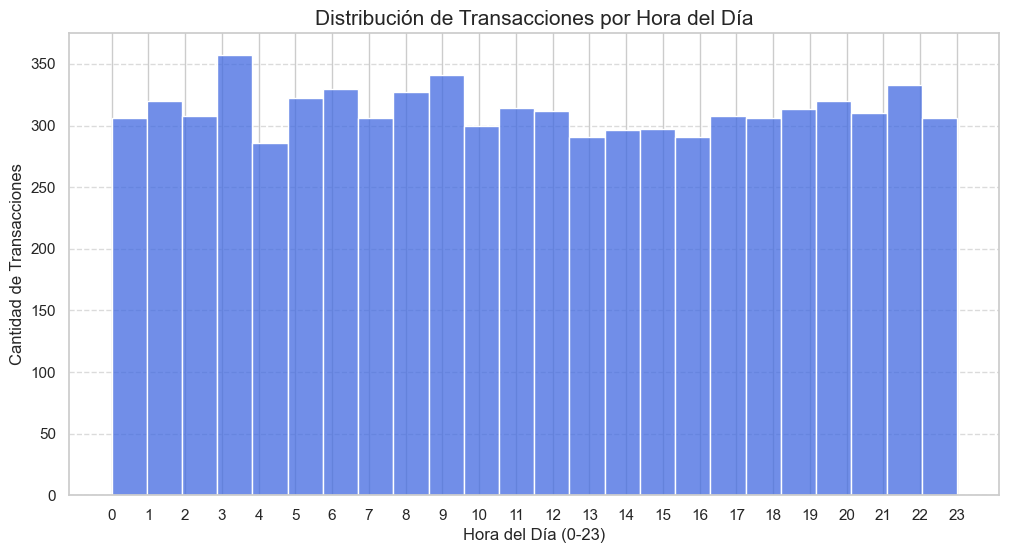

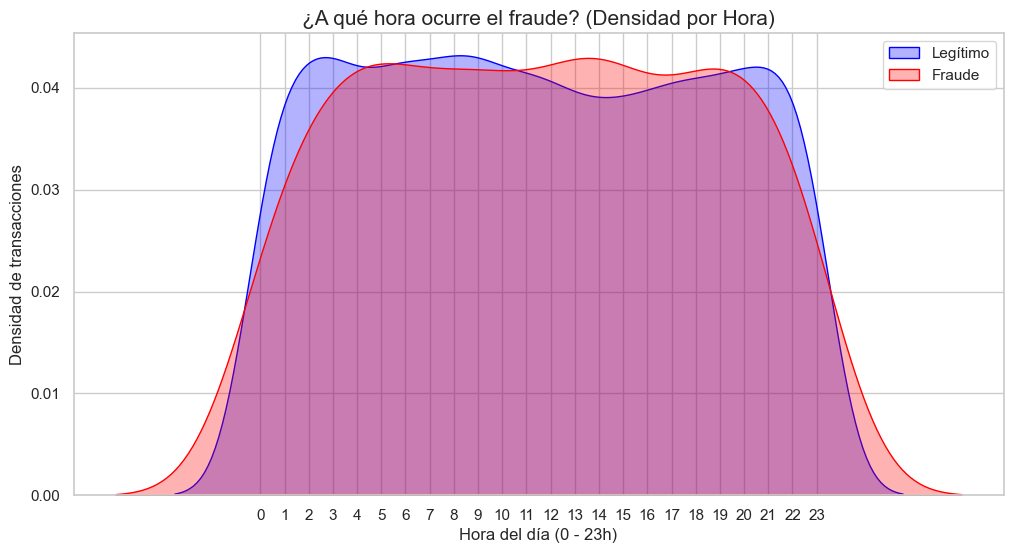

In [ ]:

print("\n🔍  Histograma")
print("-" * 40)

# Revisamos las horas en las que hay datos de transacciones, y creamos histograma para ver como se distribuyen las transacciones
df['transaction_hour'].value_counts().sort_index()

print(df['fraud_label'].value_counts(normalize=True))


plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='transaction_hour', bins=24, kde=False, color='royalblue')
plt.title('Distribución de Transacciones por Hora del Día', fontsize=15)
plt.xlabel('Hora del Día (0-23)')
plt.ylabel('Cantidad de Transacciones')
plt.xticks(range(0, 24)) # Para que aparezcan todos los números del 0 al 23
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


# 1. Configuramos el estilo

print("\n🔍  Grafico Densidad")
print("-" * 40)
sns.set_theme(style="whitegrid")

# 2. Creamos el gráfico de densidad para ver el comportamiento
plt.figure(figsize=(12, 6))

# Graficamos la distribución de la hora separando por fraude
sns.kdeplot(data=df[df['fraud_label'] == 0], x='transaction_hour', 
            label='Legítimo', fill=True, color='blue', alpha=0.3)
sns.kdeplot(data=df[df['fraud_label'] == 1], x='transaction_hour', 
            label='Fraude', fill=True, color='red', alpha=0.3)

# 3. Personalización del gráfico
plt.title('¿A qué hora ocurre el fraude? (Densidad por Hora)', fontsize=15)
plt.xlabel('Hora del día (0 - 23h)')
plt.ylabel('Densidad de transacciones')
plt.xticks(range(0, 24))
plt.legend()
plt.show()





# Conclusion:
La hora del día no se ve relacionada con el fraude, las transacciones fraudulentas estan distribuidas en todos los horarios sin ver un patrón claro.

B. ¿Cómo se distribuye el monto de las transacciones?
Queremos ver si la mayoría de las compras son pequeñas o grandes.

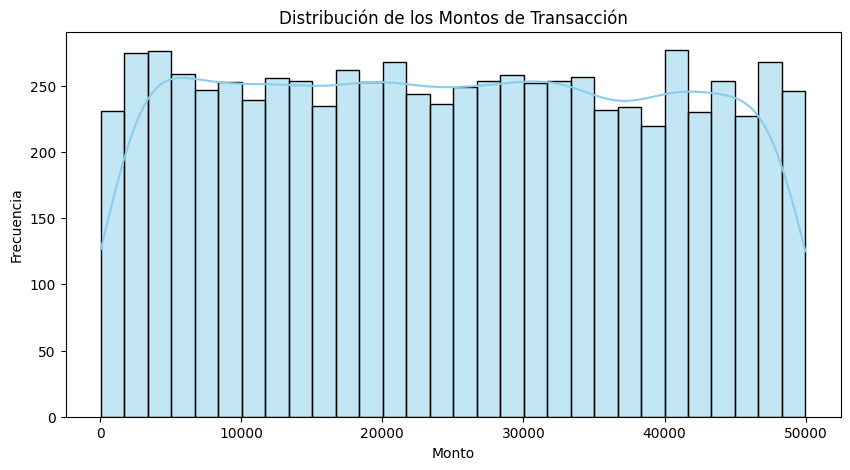

In [7]:
plt.figure(figsize=(10, 5))
sns.histplot(df['transaction_amount'], bins=30, kde=True, color='skyblue')
plt.title('Distribución de los Montos de Transacción')
plt.xlabel('Monto')
plt.ylabel('Frecuencia')
plt.show()

# Conclusion
El monto de las transacciones tiene una distribución pareja y no se observa un valor o rango de valores con frecuencias mas altas que el resto

C. ¿Podemos analizar la distribución de los score de riesgo? y ver que tan diferente es la distribución de estas transacciones versus las no fraudulentas

Riesgo de IP promedio:
fraud_label
0    0.504771
1    0.508689
Name: ip_risk_score, dtype: float64


C:\Users\USER\AppData\Local\Temp\ipykernel_17420\2646106059.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='fraud_label', y='ip_risk_score', data=df, palette='Oranges')


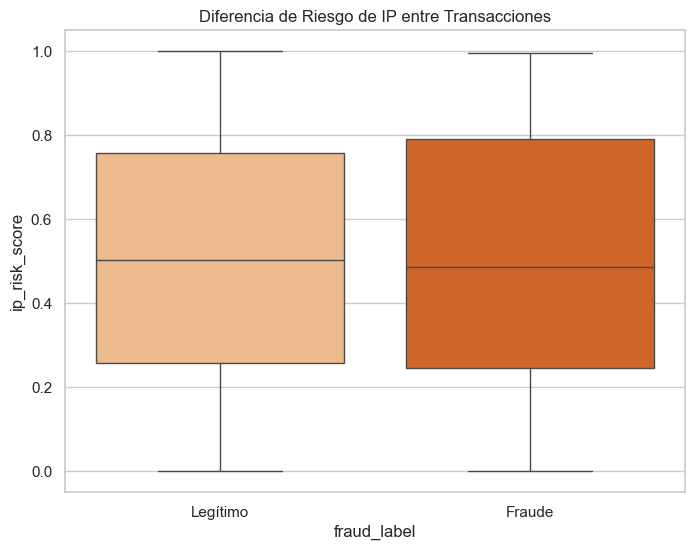

In [14]:
# Comparamos el riesgo promedio de IP entre transacciones normales y fraudes
promedio_riesgo = df.groupby('fraud_label')['ip_risk_score'].mean()
print("Riesgo de IP promedio:")
print(promedio_riesgo)

# Visualización de Boxplot para ver la diferencia clara
plt.figure(figsize=(8, 6))
sns.boxplot(x='fraud_label', y='ip_risk_score', data=df, palette='Oranges')
plt.title('Diferencia de Riesgo de IP entre Transacciones')
plt.xticks([0, 1], ['Legítimo', 'Fraude'])
plt.show()

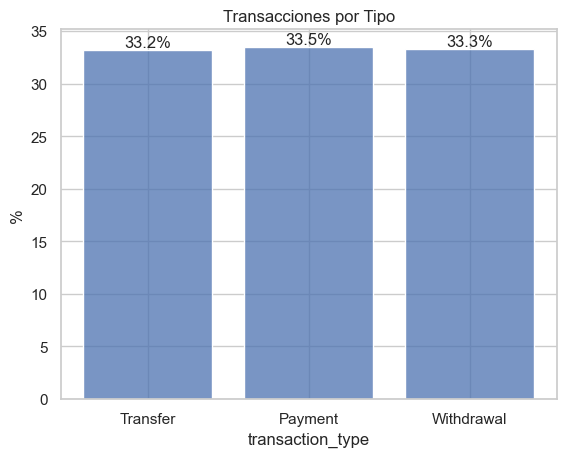

In [19]:
plt.title('Transacciones por Tipo')
ax = sns.histplot(x = 'transaction_type', bins=2, stat="percent",data=df ,multiple="dodge",shrink=0.8 )

for p in ax.patches:
    porcentaje = p.get_height()
    ax.annotate(f'{porcentaje:.1f}%', 
                (p.get_x() + p.get_width() / 2, porcentaje),
                ha='center', va='bottom')

plt.ylabel("%")
plt.show()

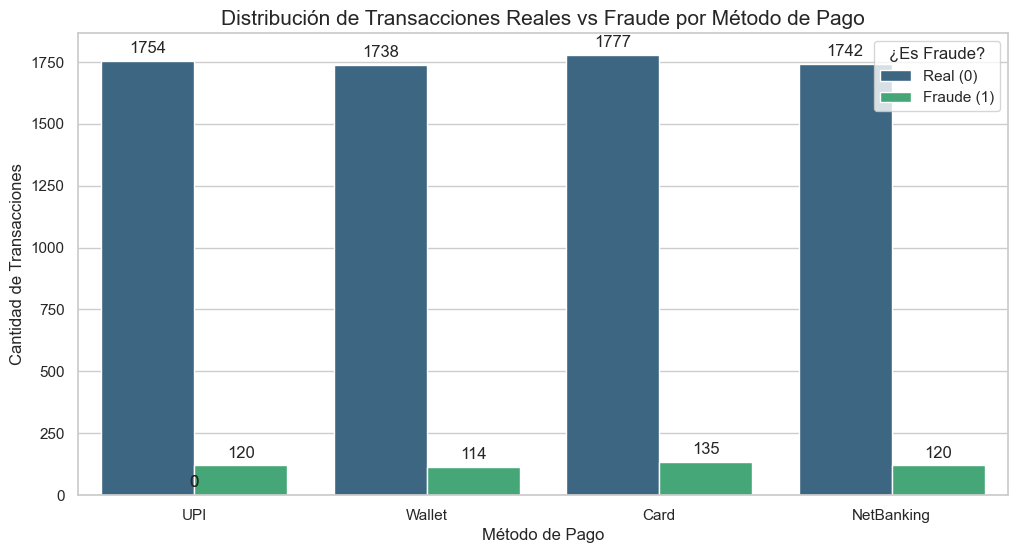

In [ ]:

plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

ax = sns.countplot(data=df, x='payment_mode', hue='fraud_label', palette='viridis')

plt.title('Distribución de Transacciones Reales vs Fraude por Método de Pago', fontsize=15)
plt.xlabel('Método de Pago', fontsize=12)
plt.ylabel('Cantidad de Transacciones', fontsize=12)
plt.legend(title='¿Es Fraude?', labels=['Real (0)', 'Fraude (1)'])

plt.show()

In [21]:
# 1. Calculamos el porcentaje de fraude por cada tipo de pago
tabla_fraude = df.groupby('payment_mode')['fraud_label'].mean() * 100

tabla_fraude = tabla_fraude.reset_index()

# 2. Renombramos las columnas para que sean claras
tabla_fraude.columns = ['Método de Pago', '% de Fraude']

# 3. Ordenamos de mayor a menor riesgo
tabla_fraude = tabla_fraude.sort_values(by='% de Fraude', ascending=False)

# 4. Mostramos la tabla con un estilo limpio
print("--- Porcentaje de Fraude por Método de Pago ---")
display(tabla_fraude)

--- Porcentaje de Fraude por Método de Pago ---


,Método de Pago,% de Fraude
0,Card,7.060669
1,NetBanking,6.444683
2,UPI,6.403415
3,Wallet,6.155508


# Conclusion
La cantidad de transacciones por tipo de transaccion y medio de pago no tienen una concentración de fraude en algun item puntual, sin embargo el porcentaje más alto de fraudes está en tarjeta de crédito y el más seguro es wallet

D. Revisar cuantos países hay en el dataset y revisar si el país tiene alguna incidencia en fraudes

In [22]:
# 1. Ver qué valores únicos hay en la ubicación
print("--- Ciudades/Ubicaciones en el dataset ---")
print(df['device_location'].unique())

# 2. Analizar la variable 'is_international'
print("\n--- Conteo de transacciones internacionales ---")
print(df['is_international'].value_counts())

--- Ciudades/Ubicaciones en el dataset ---
['Hyderabad' 'Chennai' 'Delhi' 'Mumbai' 'Bangalore']

--- Conteo de transacciones internacionales ---
is_international
0    6745
1     755
Name: count, dtype: int64


--- Ranking de Riesgo por Ciudad ---


,Ciudad,% de Fraude
0,Mumbai,7.308743
1,Hyderabad,7.125155
2,Chennai,6.198910
3,Bangalore,6.126482
4,Delhi,5.779944


C:\Users\USER\AppData\Local\Temp\ipykernel_17420\4213226323.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=fraude_ciudad, x='Ciudad', y='% de Fraude', palette='magma')


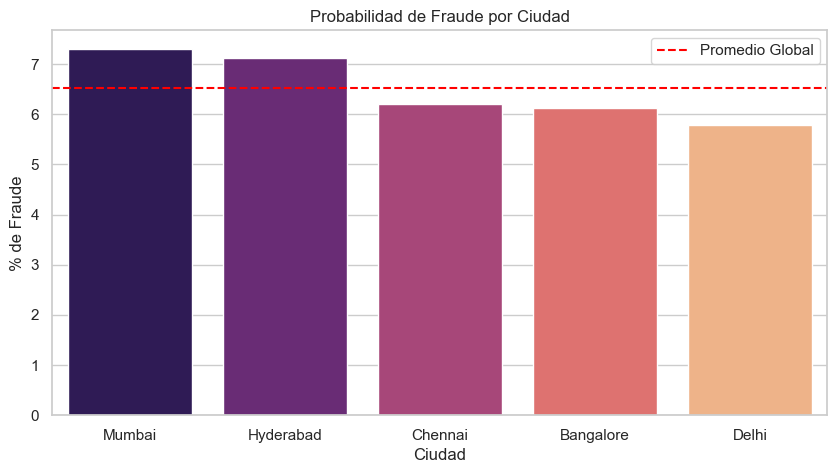

In [23]:
# Calcular el % de fraude por ciudad
fraude_ciudad = df.groupby('device_location')['fraud_label'].mean() * 100
fraude_ciudad = fraude_ciudad.sort_values(ascending=False).reset_index()
fraude_ciudad.columns = ['Ciudad', '% de Fraude']

print("--- Ranking de Riesgo por Ciudad ---")
display(fraude_ciudad)

# Gráfico de barras para comparar
plt.figure(figsize=(10, 5))
sns.barplot(data=fraude_ciudad, x='Ciudad', y='% de Fraude', palette='magma')
plt.title('Probabilidad de Fraude por Ciudad')
plt.axhline(df['fraud_label'].mean()*100, color='red', linestyle='--', label='Promedio Global')
plt.legend()
plt.show()

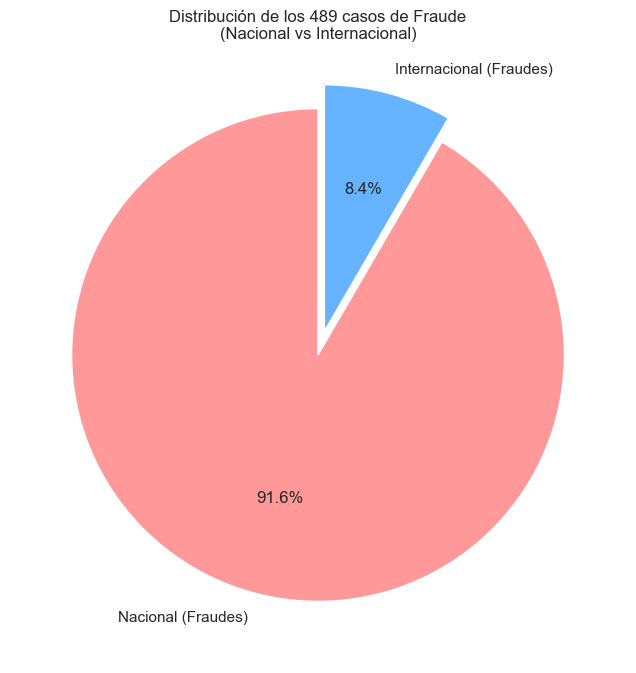

Cantidad exacta de fraudes:
Nacional (Fraudes)         448
Internacional (Fraudes)     41
dtype: int64


In [30]:
# Veamos si el fraude es más alto en transacciones internacionales
solo_fraude = df[df['fraud_label'] == 1]

# 2. Contamos cuántos hay por cada tipo (nacional vs internacional)
conteo_fraude_intl = solo_fraude.groupby('is_international').size()

# 3. Cambiamos los nombres de los índices para que el gráfico sea legible
conteo_fraude_intl.index = ['Nacional (Fraudes)', 'Internacional (Fraudes)']

# 4. Graficamos la proporción de ese "universo" de fraudes
plt.figure(figsize=(8, 8))
plt.pie(conteo_fraude_intl, 
        labels=conteo_fraude_intl.index, 
        autopct='%1.1f%%', 
        colors=['#ff9999','#66b3ff'], 
        startangle=90,
        explode=(0, 0.1))

plt.title('Distribución de los 489 casos de Fraude\n(Nacional vs Internacional)')
plt.show()


print("Cantidad exacta de fraudes:")
print(conteo_fraude_intl)

--- Análisis de Riesgo: Nacional vs Internacional ---


,Total Transacciones,% de Riesgo (Fraude)
Nacional (0),6745,6.641957
Internacional (1),755,5.430464


C:\Users\USER\AppData\Local\Temp\ipykernel_17420\1634564608.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tabla_riesgo.index, y='% de Riesgo (Fraude)', data=tabla_riesgo, palette='coolwarm')


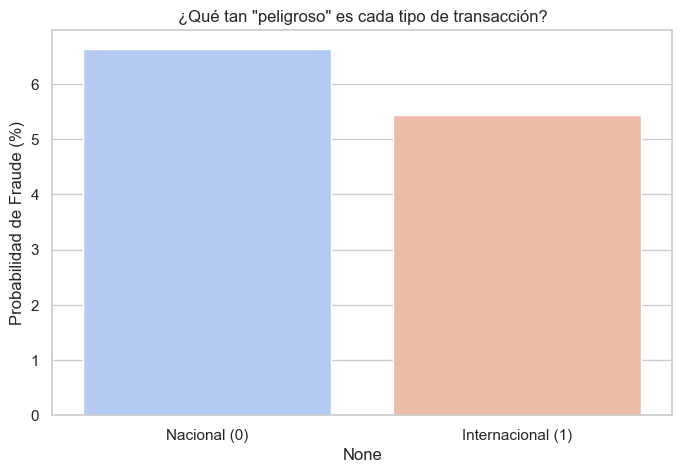

In [ ]:
# 1. Creamos una tabla de riesgo para saber cuantas transacciones por cada label hay y si las internacionales si son mas riesgosas
tabla_riesgo = df.groupby('is_international')['fraud_label'].agg(['count', 'mean'])

# 2. Formateo
tabla_riesgo['mean'] = tabla_riesgo['mean'] * 100
tabla_riesgo.columns = ['Total Transacciones', '% de Riesgo (Fraude)']
tabla_riesgo.index = ['Nacional (0)', 'Internacional (1)']

print("--- Análisis de Riesgo: Nacional vs Internacional ---")
display(tabla_riesgo)

# 3. Gráfico para comparar el riesgo directamente
plt.figure(figsize=(8, 5))
sns.barplot(x=tabla_riesgo.index, y='% de Riesgo (Fraude)', data=tabla_riesgo, palette='coolwarm')
plt.title('¿Qué tan "peligroso" es cada tipo de transacción?')
plt.ylabel('Probabilidad de Fraude (%)')
plt.show()

# Conclusion
El dataset solo tiene ciudades de India, hay 2 ciudades donde el fraude es levemente superior al resto: Mumbai y Hyderabad.
Contrario a la creencia popular, las transacciones internacionales presentan un riesgo de fraude un 18% menor que las transacciones nacionales (5.43% frente a 6.64%). Esto sugiere que los mecanismos de seguridad para pagos extranjeros son efectivos o que el patrón de ataque está enfocado en el mercado interno de India

E. Los intentos de login o la antiguedad de la cuenta se relacionan de forma positiva con el fraude?

In [32]:
# Comparamos el promedio de intentos de login entre transacciones reales y fraude
intentos_login = df.groupby('fraud_label')['login_attempts_last_24h'].mean()
print("Promedio de intentos de login en las últimas 24h:")
print(intentos_login)

Promedio de intentos de login en las últimas 24h:
fraud_label
0    4.983882
1    5.155419
Name: login_attempts_last_24h, dtype: float64


Tenemos un promedio levemente mayor de intentos de login en fraude vs transacciones genuinas